In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

%cd /content
!git clone https://github.com/dammsi/AnomalyDINO.git

%cd /content/AnomalyDINO
!git checkout b9d1c2648e3a5247437d4d953d907a8f3d994457

!pip install -q \
  "numpy==1.26.4" \
  "opencv-python==4.10.0.84" \
  matplotlib Pillow scipy scikit-learn \
  faiss-cpu tqdm tifffile PyYAML pandas

print("Commit AnomalyDINO:")
!git rev-parse HEAD

Tesla T4, 15360 MiB
/content
Cloning into 'AnomalyDINO'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 137 (delta 41), reused 31 (delta 31), pack-reused 86 (from 1)
Receiving objects: 100% (137/137), 6.87 MiB | 21.11 MiB/s, done.
Resolving deltas: 100% (76/76), done.
/content/AnomalyDINO
Note: switching to 'b9d1c2648e3a5247437d4d953d907a8f3d994457'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at b9d1c26 min

In [1]:
import numpy as np
import cv2
import torch
import faiss
import scipy
import sklearn

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("PyTorch:", torch.__version__)
print("FAISS:", faiss.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("GPU:", torch.cuda.get_device_name(0))

# Piccolo test FAISS
vectors = np.random.rand(10, 4).astype("float32")
index = faiss.IndexFlatL2(4)
index.add(vectors)
distances, indices = index.search(vectors[:1], 1)

print("Test FAISS riuscito:", indices[0, 0] == 0)

NumPy: 1.26.4
OpenCV: 4.10.0
PyTorch: 2.11.0+cu128
FAISS: 1.14.3
SciPy: 1.16.3
Scikit-learn: 1.6.1
GPU: Tesla T4
Test FAISS riuscito: True


In [2]:
%cd /content

from google.colab import files
from pathlib import Path
import zipfile
import hashlib

uploaded = files.upload()
input_zip = Path("/content") / next(iter(uploaded))

with zipfile.ZipFile(input_zip) as archive:
    archive.extractall("/content")

normal_dir = Path("/content/E05_inputs/normal_frames")
clip_path = Path(
    "/content/E05_inputs/test_clip/san_donato_pilot_85_105.mp4"
)
gt_path = Path(
    "/content/E05_inputs/annotations/"
    "test_video_san_donato_v2_reviewed_boxes.csv"
)

sha256 = hashlib.sha256(input_zip.read_bytes()).hexdigest()

print("SHA256:", sha256)
print("Frame normali:", len(list(normal_dir.glob("normal_*.jpg"))))
print("Clip presente:", clip_path.exists())
print("Ground truth presente:", gt_path.exists())

/content


Saving E05_anomalydino_inputs_v1.zip to E05_anomalydino_inputs_v1.zip
SHA256: db8118fc36199c2060a6214047a4df79580d359a9127796e7318f1b9d8141c2c
Frame normali: 200
Clip presente: True
Ground truth presente: True


In [3]:
import shutil
import cv2
import pandas as pd
import numpy as np
from pathlib import Path

dataset_root = Path("/content/E05_dataset")
reference_dir = dataset_root / "train" / "good"
normal_test_dir = dataset_root / "test" / "good"
anomaly_test_dir = dataset_root / "test" / "anomaly"

if dataset_root.exists():
    shutil.rmtree(dataset_root)

reference_dir.mkdir(parents=True)
normal_test_dir.mkdir(parents=True)
anomaly_test_dir.mkdir(parents=True)

all_normal_files = sorted(normal_dir.glob("normal_*.jpg"))

# Primi 160: pool per i riferimenti.
# Ultimi 40: validation normale cronologicamente separata.
reference_pool = all_normal_files[:160]
normal_validation_files = all_normal_files[160:]

# 16 riferimenti distribuiti uniformemente nel pool.
selected_positions = np.linspace(
    0,
    len(reference_pool) - 1,
    16,
    dtype=int,
)
reference_files = [
    reference_pool[position]
    for position in selected_positions
]

for source in reference_files:
    shutil.copy2(source, reference_dir / source.name)

for source in normal_validation_files:
    shutil.copy2(source, normal_test_dir / source.name)

# Estrazione dei 500 frame anomali
cap = cv2.VideoCapture(str(clip_path))
fps = cap.get(cv2.CAP_PROP_FPS)
anomaly_count = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break

    output_path = anomaly_test_dir / f"anomaly_{anomaly_count:05d}.jpg"
    cv2.imwrite(str(output_path), frame)
    anomaly_count += 1

cap.release()

# Manifest del protocollo
normal_metadata = pd.read_csv(normal_dir / "frames.csv")
normal_metadata = normal_metadata.set_index("filename")

manifest_rows = []

for source in reference_files:
    row = normal_metadata.loc[source.name]
    manifest_rows.append({
        "filename": source.name,
        "split": "normal_reference",
        "label": 0,
        "source_video": row["source_video"],
        "source_frame": int(row["frame_index"]),
        "timestamp": float(row["timestamp"]),
    })

for source in normal_validation_files:
    row = normal_metadata.loc[source.name]
    manifest_rows.append({
        "filename": source.name,
        "split": "normal_validation",
        "label": 0,
        "source_video": row["source_video"],
        "source_frame": int(row["frame_index"]),
        "timestamp": float(row["timestamp"]),
    })

for clip_frame in range(anomaly_count):
    manifest_rows.append({
        "filename": f"anomaly_{clip_frame:05d}.jpg",
        "split": "anomaly_test",
        "label": 1,
        "source_video": "test_video_san_donato.mp4",
        "source_frame": 2125 + clip_frame,
        "timestamp": (2125 + clip_frame) / fps,
    })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv("/content/E05_dataset_manifest.csv", index=False)

print("Riferimenti normali:", len(reference_files))
print("Validation normale:", len(normal_validation_files))
print("Test anomalo:", anomaly_count)
print("FPS clip:", fps)
print("Riferimenti selezionati:")
print([path.name for path in reference_files])

Riferimenti normali: 16
Validation normale: 40
Test anomalo: 500
FPS clip: 24.999
Riferimenti selezionati:
['normal_0001.jpg', 'normal_0011.jpg', 'normal_0022.jpg', 'normal_0032.jpg', 'normal_0043.jpg', 'normal_0054.jpg', 'normal_0064.jpg', 'normal_0075.jpg', 'normal_0085.jpg', 'normal_0096.jpg', 'normal_0107.jpg', 'normal_0117.jpg', 'normal_0128.jpg', 'normal_0138.jpg', 'normal_0149.jpg', 'normal_0160.jpg']


In [4]:
%cd /content/AnomalyDINO

import subprocess
import torch
from src.backbones import get_model

MODEL_NAME = "dinov2_vits14"
RESOLUTION = 448
DEVICE = "cuda"

model = get_model(
    MODEL_NAME,
    DEVICE,
    smaller_edge_size=RESOLUTION,
)

sample_reference = str(reference_files[0])
sample_tensor, sample_grid = model.prepare_image(sample_reference)
sample_features = model.extract_features(sample_tensor)

# Commit del repository DINOv2 scaricato da torch.hub
hub_dir = Path(torch.hub.get_dir())
dinov2_repositories = list(hub_dir.glob("*dinov2*"))

dinov2_commit = "unknown"

for repository in dinov2_repositories:
    if (repository / ".git").exists():
        dinov2_commit = subprocess.check_output(
            ["git", "-C", str(repository), "rev-parse", "HEAD"],
            text=True,
        ).strip()
        break

print("Modello:", MODEL_NAME)
print("Risoluzione lato corto:", RESOLUTION)
print("Griglia patch:", sample_grid)
print("Feature:", sample_features.shape)
print("Patch size:", model.model.patch_size)
print("Commit DINOv2:", dinov2_commit)
print("GPU:", torch.cuda.get_device_name(0))

/content/AnomalyDINO
Loading model: dinov2_vits14
Device: cuda
Smaller edge size: 448
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 222MB/s]


Modello: dinov2_vits14
Risoluzione lato corto: 448
Griglia patch: (32, 40)
Feature: (1280, 384)
Patch size: 14
Commit DINOv2: unknown
GPU: Tesla T4


In [5]:
import time
import torch.nn.functional as F
from tqdm.auto import tqdm

reference_feature_blocks = []

start_time = time.time()

for image_path in tqdm(
    reference_files,
    desc="Costruzione memoria normale",
):
    image_tensor, grid_size = model.prepare_image(str(image_path))
    features = model.extract_features(image_tensor)
    reference_feature_blocks.append(features.astype("float32"))

reference_features_np = np.concatenate(
    reference_feature_blocks,
    axis=0,
)

normal_memory = torch.from_numpy(
    reference_features_np
).to("cuda")

normal_memory = F.normalize(
    normal_memory,
    p=2,
    dim=1,
)

memory_build_seconds = time.time() - start_time

print("Riferimenti:", len(reference_files))
print("Patch per immagine:", reference_feature_blocks[0].shape[0])
print("Dimensione feature:", reference_feature_blocks[0].shape[1])
print("Memoria complessiva:", tuple(normal_memory.shape))
print(
    "Memoria GPU:",
    round(normal_memory.numel() * 4 / 1024**2, 2),
    "MB",
)
print(
    "Tempo costruzione:",
    round(memory_build_seconds, 3),
    "secondi",
)

Costruzione memoria normale:   0%|          | 0/16 [00:00<?, ?it/s]

Riferimenti: 16
Patch per immagine: 1280
Dimensione feature: 384
Memoria complessiva: (20480, 384)
Memoria GPU: 30.0 MB
Tempo costruzione: 1.162 secondi


Score frame normale: 0.18125857412815094
Score frame anomalo: 0.7127177119255066
Forma anomaly map: (32, 40)
Tempo totale due immagini: 0.19 s


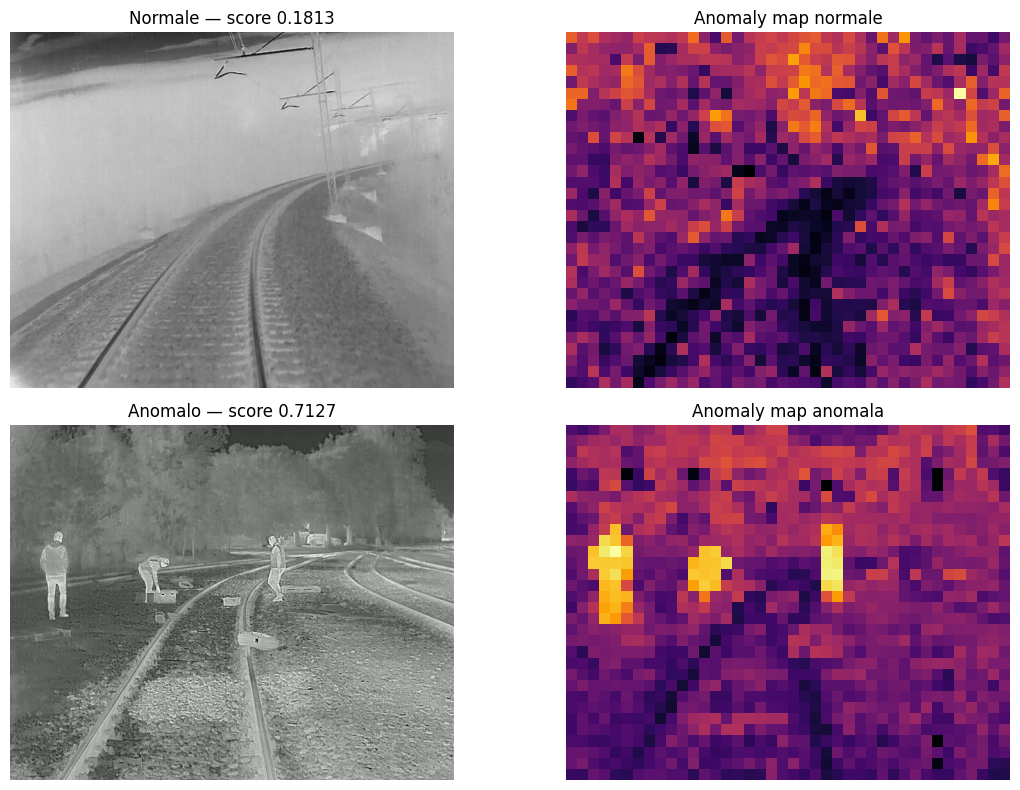

In [8]:
normal_memory_transposed = normal_memory.T.contiguous()

def score_anomalydino_image(image_path, query_chunk_size=256):
    image_tensor, grid_size = model.prepare_image(str(image_path))
    features_np = model.extract_features(image_tensor).astype("float32")

    query_features = torch.from_numpy(features_np).to("cuda")
    query_features = F.normalize(query_features, p=2, dim=1)

    distance_chunks = []

    with torch.inference_mode():
        for start in range(0, len(query_features), query_chunk_size):
            query_chunk = query_features[
                start:start + query_chunk_size
            ]

            maximum_similarity = torch.matmul(
                query_chunk,
                normal_memory_transposed,
            ).max(dim=1).values

            distances = torch.clamp(
                1.0 - maximum_similarity,
                min=0.0,
            )
            distance_chunks.append(distances.cpu())

    patch_distances = torch.cat(distance_chunks).numpy()
    patch_map = patch_distances.reshape(grid_size)

    top_count = max(1, int(len(patch_distances) * 0.01))
    image_score = float(
        np.mean(np.sort(patch_distances)[-top_count:])
    )

    return image_score, patch_map


normal_probe = normal_test_dir / normal_validation_files[0].name
anomaly_probe = anomaly_test_dir / "anomaly_00300.jpg"

start = time.time()
normal_score, normal_map = score_anomalydino_image(normal_probe)
anomaly_score, anomaly_map = score_anomalydino_image(anomaly_probe)
probe_seconds = time.time() - start

print("Score frame normale:", normal_score)
print("Score frame anomalo:", anomaly_score)
print("Forma anomaly map:", anomaly_map.shape)
print("Tempo totale due immagini:", round(probe_seconds, 3), "s")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(Image.open(normal_probe))
axes[0, 0].set_title(f"Normale — score {normal_score:.4f}")

axes[0, 1].imshow(normal_map, cmap="inferno")
axes[0, 1].set_title("Anomaly map normale")

axes[1, 0].imshow(Image.open(anomaly_probe))
axes[1, 0].set_title(f"Anomalo — score {anomaly_score:.4f}")

axes[1, 1].imshow(anomaly_map, cmap="inferno")
axes[1, 1].set_title("Anomaly map anomala")

for axis in axes.ravel():
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    "/content/E05_probe_normal_vs_anomaly.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [9]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)

normal_calibration_files = normal_validation_files[:20]
normal_evaluation_files = normal_validation_files[20:]

test_items = []

for source in normal_calibration_files:
    metadata_row = normal_metadata.loc[source.name]
    test_items.append({
        "path": normal_test_dir / source.name,
        "filename": source.name,
        "role": "normal_calibration",
        "label": 0,
        "source_frame": int(metadata_row["frame_index"]),
        "timestamp": float(metadata_row["timestamp"]),
    })

for source in normal_evaluation_files:
    metadata_row = normal_metadata.loc[source.name]
    test_items.append({
        "path": normal_test_dir / source.name,
        "filename": source.name,
        "role": "normal_test",
        "label": 0,
        "source_frame": int(metadata_row["frame_index"]),
        "timestamp": float(metadata_row["timestamp"]),
    })

for clip_frame in range(anomaly_count):
    test_items.append({
        "path": anomaly_test_dir / f"anomaly_{clip_frame:05d}.jpg",
        "filename": f"anomaly_{clip_frame:05d}.jpg",
        "role": "anomaly_test",
        "label": 1,
        "source_frame": 2125 + clip_frame,
        "timestamp": (2125 + clip_frame) / fps,
    })

result_rows = []
raw_maps = []

torch.cuda.synchronize()
inference_start = time.time()

for item in tqdm(test_items, desc="Inferenza AnomalyDINO"):
    score, raw_map = score_anomalydino_image(item["path"])

    result_rows.append({
        "filename": item["filename"],
        "role": item["role"],
        "label": item["label"],
        "source_frame": item["source_frame"],
        "timestamp": item["timestamp"],
        "anomaly_score": score,
    })
    raw_maps.append(raw_map.astype(np.float32))

torch.cuda.synchronize()
inference_seconds = time.time() - inference_start

scores_df = pd.DataFrame(result_rows)
raw_maps_array = np.stack(raw_maps)

# Soglia scelta soltanto sui 20 normali di calibrazione
calibration_scores = scores_df.loc[
    scores_df["role"] == "normal_calibration",
    "anomaly_score",
].to_numpy()

THRESHOLD_QUANTILE = 0.95
anomaly_threshold = float(
    np.quantile(calibration_scores, THRESHOLD_QUANTILE)
)

scores_df["predicted_anomaly"] = (
    scores_df["anomaly_score"] >= anomaly_threshold
).astype(int)

# Valutazione: 20 normali indipendenti + 500 anomali
evaluation_df = scores_df[
    scores_df["role"].isin(["normal_test", "anomaly_test"])
].copy()

y_true = evaluation_df["label"].to_numpy()
y_score = evaluation_df["anomaly_score"].to_numpy()
y_pred = evaluation_df["predicted_anomaly"].to_numpy()

tn = int(((y_true == 0) & (y_pred == 0)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
tp = int(((y_true == 1) & (y_pred == 1)).sum())

classification_summary = pd.DataFrame([{
    "experiment_id": "E05_v1_anomalydino_16shot",
    "threshold_source": "95th_percentile_20_normal_calibration",
    "anomaly_threshold": anomaly_threshold,
    "normal_test_frames": 20,
    "anomaly_test_frames": 500,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp,
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "auroc": roc_auc_score(y_true, y_score),
    "average_precision": average_precision_score(y_true, y_score),
    "inference_seconds": inference_seconds,
    "frames_per_second": len(test_items) / inference_seconds,
}])

scores_df.to_csv(
    "/content/E05_anomalydino_scores.csv",
    index=False,
)
classification_summary.to_csv(
    "/content/E05_classification_summary.csv",
    index=False,
)

np.savez_compressed(
    "/content/E05_raw_anomaly_maps.npz",
    maps=raw_maps_array,
    filenames=np.array(scores_df["filename"]),
    roles=np.array(scores_df["role"]),
    source_frames=scores_df["source_frame"].to_numpy(),
    scores=scores_df["anomaly_score"].to_numpy(),
    grid_size=np.array(raw_maps_array.shape[1:]),
)

print("Statistiche score:")
display(
    scores_df.groupby("role")["anomaly_score"].agg(
        ["count", "min", "median", "mean", "max"]
    )
)

print("Soglia:", anomaly_threshold)
print("Metriche indipendenti:")
display(classification_summary)

Inferenza AnomalyDINO:   0%|          | 0/540 [00:00<?, ?it/s]

Statistiche score:


,count,min,median,mean,max
role,,,,,
anomaly_test,500,0.619968,0.677805,0.679091,0.746290
normal_calibration,20,0.181259,0.261972,0.252218,0.301935
normal_test,20,0.253884,0.266436,0.272748,0.302825


Soglia: 0.28902236819267274
Metriche indipendenti:


,experiment_id,threshold_source,anomaly_threshold,normal_test_frames,anomaly_test_frames,tn,fp,fn,tp,precision,recall,f1,auroc,average_precision,inference_seconds,frames_per_second
0,E05_v1_anomalydino_16shot,95th_percentile_20_normal_calibration,0.289022,20,500,16,4,0,500,0.992063,1.0,0.996016,1.0,1.0,44.73669,12.070629


In [10]:
from scipy.ndimage import gaussian_filter

IMAGE_WIDTH = 640
IMAGE_HEIGHT = 512
LOCALIZATION_QUANTILE = 0.995

def upscale_anomaly_map(raw_map):
    resized = cv2.resize(
        raw_map,
        (IMAGE_WIDTH, IMAGE_HEIGHT),
        interpolation=cv2.INTER_LINEAR,
    )
    return gaussian_filter(resized, sigma=4)


# Soglia spaziale calcolata soltanto sulle mappe normali di calibrazione
calibration_indices = scores_df.index[
    scores_df["role"] == "normal_calibration"
].to_numpy()

calibration_pixel_values = []

for index in calibration_indices:
    calibration_pixel_values.append(
        upscale_anomaly_map(raw_maps_array[index]).ravel()
    )

calibration_pixel_values = np.concatenate(
    calibration_pixel_values
)

localization_threshold = float(
    np.quantile(
        calibration_pixel_values,
        LOCALIZATION_QUANTILE,
    )
)

gt_df = pd.read_csv(gt_path)

visible_gt = gt_df[
    (gt_df["outside"] == 0)
    & gt_df["frame"].between(2125, 2624)
].copy()

person_gt = visible_gt[
    visible_gt["tipo"] == "persona"
].copy()

pointing_rows = []

anomaly_indices = scores_df.index[
    scores_df["role"] == "anomaly_test"
].to_numpy()

for result_index in tqdm(
    anomaly_indices,
    desc="Pointing game",
):
    source_frame = int(
        scores_df.loc[result_index, "source_frame"]
    )

    full_map = upscale_anomaly_map(
        raw_maps_array[result_index]
    )

    maximum_position = np.unravel_index(
        np.argmax(full_map),
        full_map.shape,
    )
    maximum_y, maximum_x = maximum_position
    maximum_value = float(full_map[maximum_y, maximum_x])

    frame_person_boxes = person_gt[
        person_gt["frame"] == source_frame
    ]
    frame_all_boxes = visible_gt[
        visible_gt["frame"] == source_frame
    ]

    person_hits = frame_person_boxes[
        (frame_person_boxes["xtl"] <= maximum_x)
        & (frame_person_boxes["xbr"] >= maximum_x)
        & (frame_person_boxes["ytl"] <= maximum_y)
        & (frame_person_boxes["ybr"] >= maximum_y)
    ]

    all_hits = frame_all_boxes[
        (frame_all_boxes["xtl"] <= maximum_x)
        & (frame_all_boxes["xbr"] >= maximum_x)
        & (frame_all_boxes["ytl"] <= maximum_y)
        & (frame_all_boxes["ybr"] >= maximum_y)
    ]

    pointing_rows.append({
        "source_frame": source_frame,
        "clip_frame": source_frame - 2125,
        "max_x": int(maximum_x),
        "max_y": int(maximum_y),
        "max_value": maximum_value,
        "person_gt_boxes": len(frame_person_boxes),
        "all_gt_boxes": len(frame_all_boxes),
        "hit_person": int(len(person_hits) > 0),
        "hit_any_annotation": int(len(all_hits) > 0),
        "matched_person_track_ids": ",".join(
            map(str, person_hits["track_id"].tolist())
        ),
    })

pointing_df = pd.DataFrame(pointing_rows)

pointing_summary = pd.DataFrame([
    {
        "scope": "persona_only",
        "frames": len(pointing_df),
        "hits": int(pointing_df["hit_person"].sum()),
        "pointing_accuracy": pointing_df["hit_person"].mean(),
        "localization_threshold": localization_threshold,
    },
    {
        "scope": "all_visible_annotations",
        "frames": len(pointing_df),
        "hits": int(
            pointing_df["hit_any_annotation"].sum()
        ),
        "pointing_accuracy":
            pointing_df["hit_any_annotation"].mean(),
        "localization_threshold": localization_threshold,
    },
])

pointing_df.to_csv(
    "/content/E05_pointing_game_per_frame.csv",
    index=False,
)
pointing_summary.to_csv(
    "/content/E05_pointing_game_summary.csv",
    index=False,
)

print("Soglia spaziale:", localization_threshold)
display(pointing_summary)

Pointing game:   0%|          | 0/500 [00:00<?, ?it/s]

Soglia spaziale: 0.22833819724619386


,scope,frames,hits,pointing_accuracy,localization_threshold
0,persona_only,500,478,0.956,0.228338
1,all_visible_annotations,500,478,0.956,0.228338


In [11]:
MIN_COMPONENT_AREA = 200
ADAPTIVE_QUANTILE = 0.99


def extract_component_boxes(binary_mask):
    binary_uint8 = binary_mask.astype(np.uint8)

    component_count, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary_uint8,
            connectivity=8,
        )
    )

    boxes = []

    for component_id in range(1, component_count):
        x = int(stats[component_id, cv2.CC_STAT_LEFT])
        y = int(stats[component_id, cv2.CC_STAT_TOP])
        w = int(stats[component_id, cv2.CC_STAT_WIDTH])
        h = int(stats[component_id, cv2.CC_STAT_HEIGHT])
        area = int(stats[component_id, cv2.CC_STAT_AREA])

        if area < MIN_COMPONENT_AREA:
            continue

        boxes.append({
            "xtl": x,
            "ytl": y,
            "xbr": x + w,
            "ybr": y + h,
            "area": area,
        })

    return boxes


def box_iou_values(candidate, ground_truth):
    x1 = max(candidate["xtl"], ground_truth["xtl"])
    y1 = max(candidate["ytl"], ground_truth["ytl"])
    x2 = min(candidate["xbr"], ground_truth["xbr"])
    y2 = min(candidate["ybr"], ground_truth["ybr"])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    candidate_area = (
        (candidate["xbr"] - candidate["xtl"])
        * (candidate["ybr"] - candidate["ytl"])
    )
    gt_area = (
        (ground_truth["xbr"] - ground_truth["xtl"])
        * (ground_truth["ybr"] - ground_truth["ytl"])
    )

    return intersection / max(
        candidate_area + gt_area - intersection,
        1e-9,
    )


def greedy_box_matching(candidate_boxes, gt_boxes, iou_threshold):
    possible_matches = []

    for candidate_index, candidate in enumerate(candidate_boxes):
        for gt_index, ground_truth in enumerate(gt_boxes):
            iou = box_iou_values(candidate, ground_truth)
            possible_matches.append(
                (iou, candidate_index, gt_index)
            )

    possible_matches.sort(reverse=True)

    matched_candidates = set()
    matched_gt = set()
    matches = []

    for iou, candidate_index, gt_index in possible_matches:
        if iou < iou_threshold:
            break
        if candidate_index in matched_candidates:
            continue
        if gt_index in matched_gt:
            continue

        matched_candidates.add(candidate_index)
        matched_gt.add(gt_index)
        matches.append((candidate_index, gt_index, iou))

    return matches


methods = {
    "normal_calibrated_absolute": lambda full_map:
        localization_threshold,
    "frame_adaptive_top1pct": lambda full_map:
        float(np.quantile(full_map, ADAPTIVE_QUANTILE)),
}

candidate_rows = []
evaluation_accumulators = {
    method: {
        threshold: {
            "tp": 0,
            "fp": 0,
            "fn": 0,
            "frames_with_match": 0,
        }
        for threshold in [0.30, 0.50]
    }
    for method in methods
}

for result_index in tqdm(
    anomaly_indices,
    desc="Mappe → box",
):
    source_frame = int(
        scores_df.loc[result_index, "source_frame"]
    )
    full_map = upscale_anomaly_map(
        raw_maps_array[result_index]
    )

    frame_gt_table = person_gt[
        person_gt["frame"] == source_frame
    ]
    gt_boxes = frame_gt_table[
        ["xtl", "ytl", "xbr", "ybr"]
    ].to_dict("records")

    for method_name, threshold_function in methods.items():
        threshold_value = threshold_function(full_map)
        binary_mask = full_map >= threshold_value
        candidate_boxes = extract_component_boxes(binary_mask)

        for candidate_id, candidate in enumerate(candidate_boxes):
            candidate_rows.append({
                "method": method_name,
                "source_frame": source_frame,
                "clip_frame": source_frame - 2125,
                "candidate_id": candidate_id,
                "threshold_value": threshold_value,
                **candidate,
            })

        for iou_threshold in [0.30, 0.50]:
            matches = greedy_box_matching(
                candidate_boxes,
                gt_boxes,
                iou_threshold,
            )

            accumulator = evaluation_accumulators[
                method_name
            ][iou_threshold]

            accumulator["tp"] += len(matches)
            accumulator["fp"] += (
                len(candidate_boxes) - len(matches)
            )
            accumulator["fn"] += (
                len(gt_boxes) - len(matches)
            )
            accumulator["frames_with_match"] += int(
                len(matches) > 0
            )

candidate_boxes_df = pd.DataFrame(candidate_rows)

box_summary_rows = []

for method_name, threshold_results in (
    evaluation_accumulators.items()
):
    for iou_threshold, values in threshold_results.items():
        tp = values["tp"]
        fp = values["fp"]
        fn = values["fn"]

        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = (
            2 * precision * recall
            / max(precision + recall, 1e-9)
        )

        box_summary_rows.append({
            "method": method_name,
            "iou_threshold": iou_threshold,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "frames_with_match":
                values["frames_with_match"],
            "frame_hit_rate":
                values["frames_with_match"] / 500,
            "min_component_area": MIN_COMPONENT_AREA,
        })

box_summary = pd.DataFrame(box_summary_rows)

candidate_boxes_df.to_csv(
    "/content/E05_candidate_boxes.csv",
    index=False,
)
box_summary.to_csv(
    "/content/E05_box_localization_summary.csv",
    index=False,
)

display(box_summary)

Mappe → box:   0%|          | 0/500 [00:00<?, ?it/s]

,method,iou_threshold,tp,fp,fn,precision,recall,f1,frames_with_match,frame_hit_rate,min_component_area
0,normal_calibrated_absolute,0.3,26,4124,3706,0.006265,0.006967,0.006597,26,0.052,200
1,normal_calibrated_absolute,0.5,0,4150,3732,0.000000,0.000000,0.000000,0,0.000,200
2,frame_adaptive_top1pct,0.3,902,309,2830,0.744839,0.241693,0.364961,500,1.000,200
3,frame_adaptive_top1pct,0.5,354,857,3378,0.292320,0.094855,0.143233,324,0.648,200


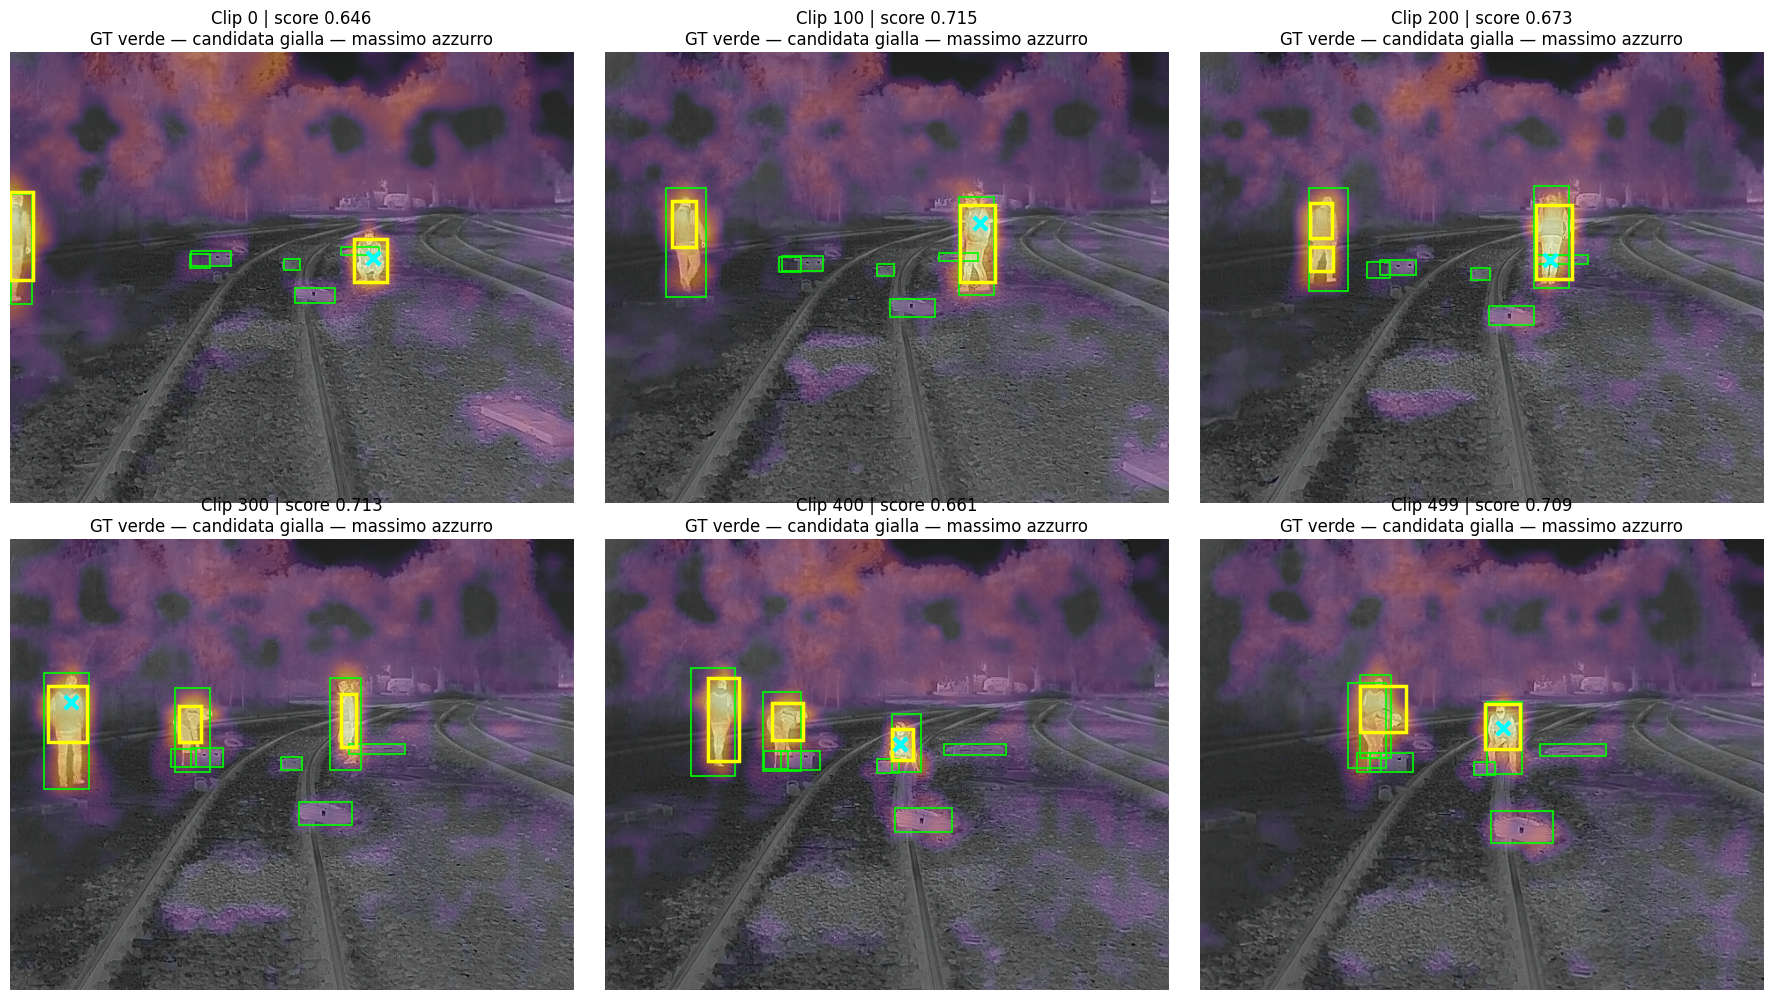

In [12]:
from matplotlib.patches import Rectangle

selected_clip_frames = [0, 100, 200, 300, 400, 499]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, clip_frame in zip(
    axes.ravel(),
    selected_clip_frames,
):
    source_frame = 2125 + clip_frame

    result_index = scores_df.index[
        (scores_df["role"] == "anomaly_test")
        & (scores_df["source_frame"] == source_frame)
    ][0]

    image_path = (
        anomaly_test_dir / f"anomaly_{clip_frame:05d}.jpg"
    )
    image = np.array(Image.open(image_path).convert("RGB"))
    full_map = upscale_anomaly_map(
        raw_maps_array[result_index]
    )

    axis.imshow(image)
    axis.imshow(
        full_map,
        cmap="inferno",
        alpha=0.45,
        vmin=localization_threshold,
        vmax=float(np.quantile(full_map, 0.999)),
    )

    # Ground truth persona: verde
    frame_gt = person_gt[
        person_gt["frame"] == source_frame
    ]

    for _, box in frame_gt.iterrows():
        axis.add_patch(
            Rectangle(
                (box["xtl"], box["ytl"]),
                box["xbr"] - box["xtl"],
                box["ybr"] - box["ytl"],
                edgecolor="lime",
                facecolor="none",
                linewidth=1.2,
            )
        )

    # Box candidate top 1%: giallo
    frame_candidates = candidate_boxes_df[
        (
            candidate_boxes_df["method"]
            == "frame_adaptive_top1pct"
        )
        & (
            candidate_boxes_df["source_frame"]
            == source_frame
        )
    ]

    for _, box in frame_candidates.iterrows():
        axis.add_patch(
            Rectangle(
                (box["xtl"], box["ytl"]),
                box["xbr"] - box["xtl"],
                box["ybr"] - box["ytl"],
                edgecolor="yellow",
                facecolor="none",
                linewidth=2.5,
            )
        )

    # Massimo della heatmap: X azzurra
    point = pointing_df[
        pointing_df["source_frame"] == source_frame
    ].iloc[0]

    axis.scatter(
        point["max_x"],
        point["max_y"],
        marker="x",
        s=90,
        linewidths=3,
        color="cyan",
    )

    score = scores_df.loc[
        result_index,
        "anomaly_score",
    ]

    axis.set_title(
        f"Clip {clip_frame} | score {score:.3f}\n"
        "GT verde — candidata gialla — massimo azzurro"
    )
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    "/content/E05_anomalydino_qualitative_six_frames.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

Falsi positivi normali: 4


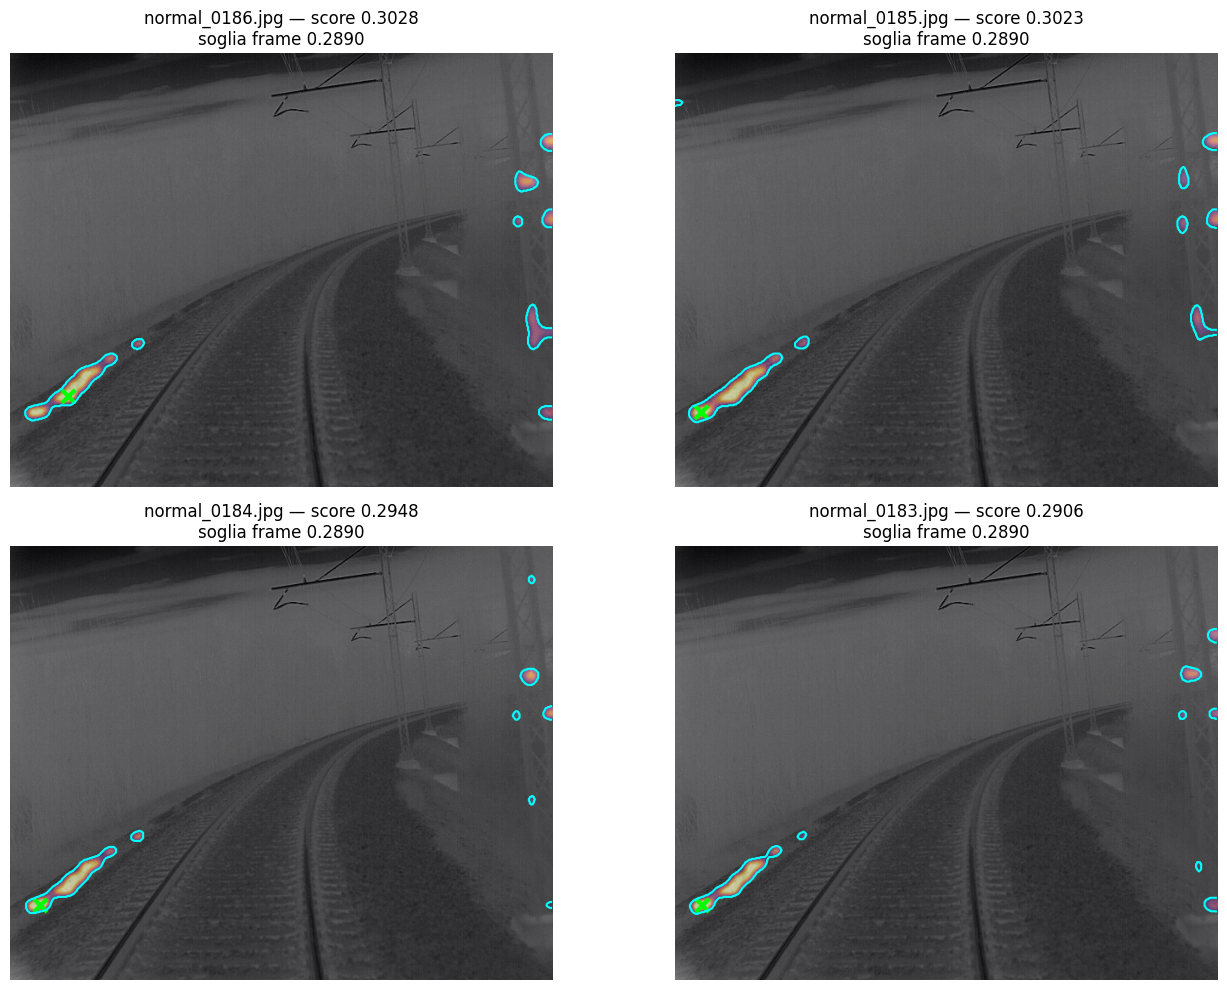

In [13]:
false_positive_df = scores_df[
    (scores_df["role"] == "normal_test")
    & (scores_df["predicted_anomaly"] == 1)
].sort_values(
    "anomaly_score",
    ascending=False,
)

print("Falsi positivi normali:", len(false_positive_df))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for axis, (result_index, row) in zip(
    axes,
    false_positive_df.iterrows(),
):
    image_path = normal_test_dir / row["filename"]
    image = np.array(Image.open(image_path).convert("RGB"))
    full_map = upscale_anomaly_map(
        raw_maps_array[result_index]
    )

    maximum_y, maximum_x = np.unravel_index(
        np.argmax(full_map),
        full_map.shape,
    )

    axis.imshow(image)
    axis.imshow(
        full_map,
        cmap="inferno",
        alpha=0.50,
        vmin=localization_threshold,
        vmax=float(np.quantile(full_map, 0.999)),
    )

    axis.contour(
        full_map >= localization_threshold,
        levels=[0.5],
        colors=["cyan"],
        linewidths=1.5,
    )

    axis.scatter(
        maximum_x,
        maximum_y,
        marker="x",
        s=90,
        linewidths=3,
        color="lime",
    )

    axis.set_title(
        f"{row['filename']} — score {row['anomaly_score']:.4f}\n"
        f"soglia frame {anomaly_threshold:.4f}"
    )
    axis.axis("off")

for axis in axes[len(false_positive_df):]:
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    "/content/E05_normal_false_positives.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

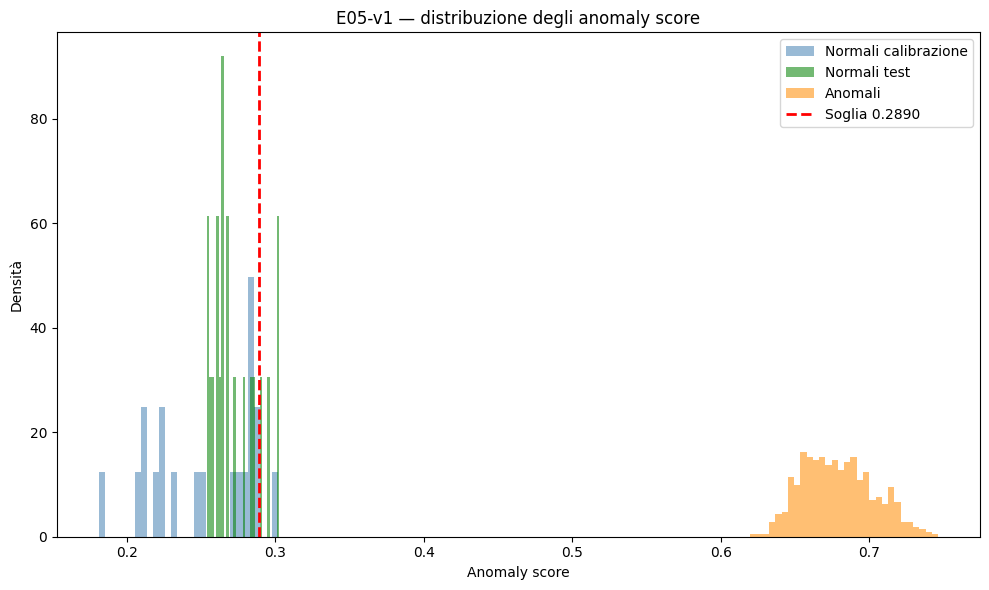

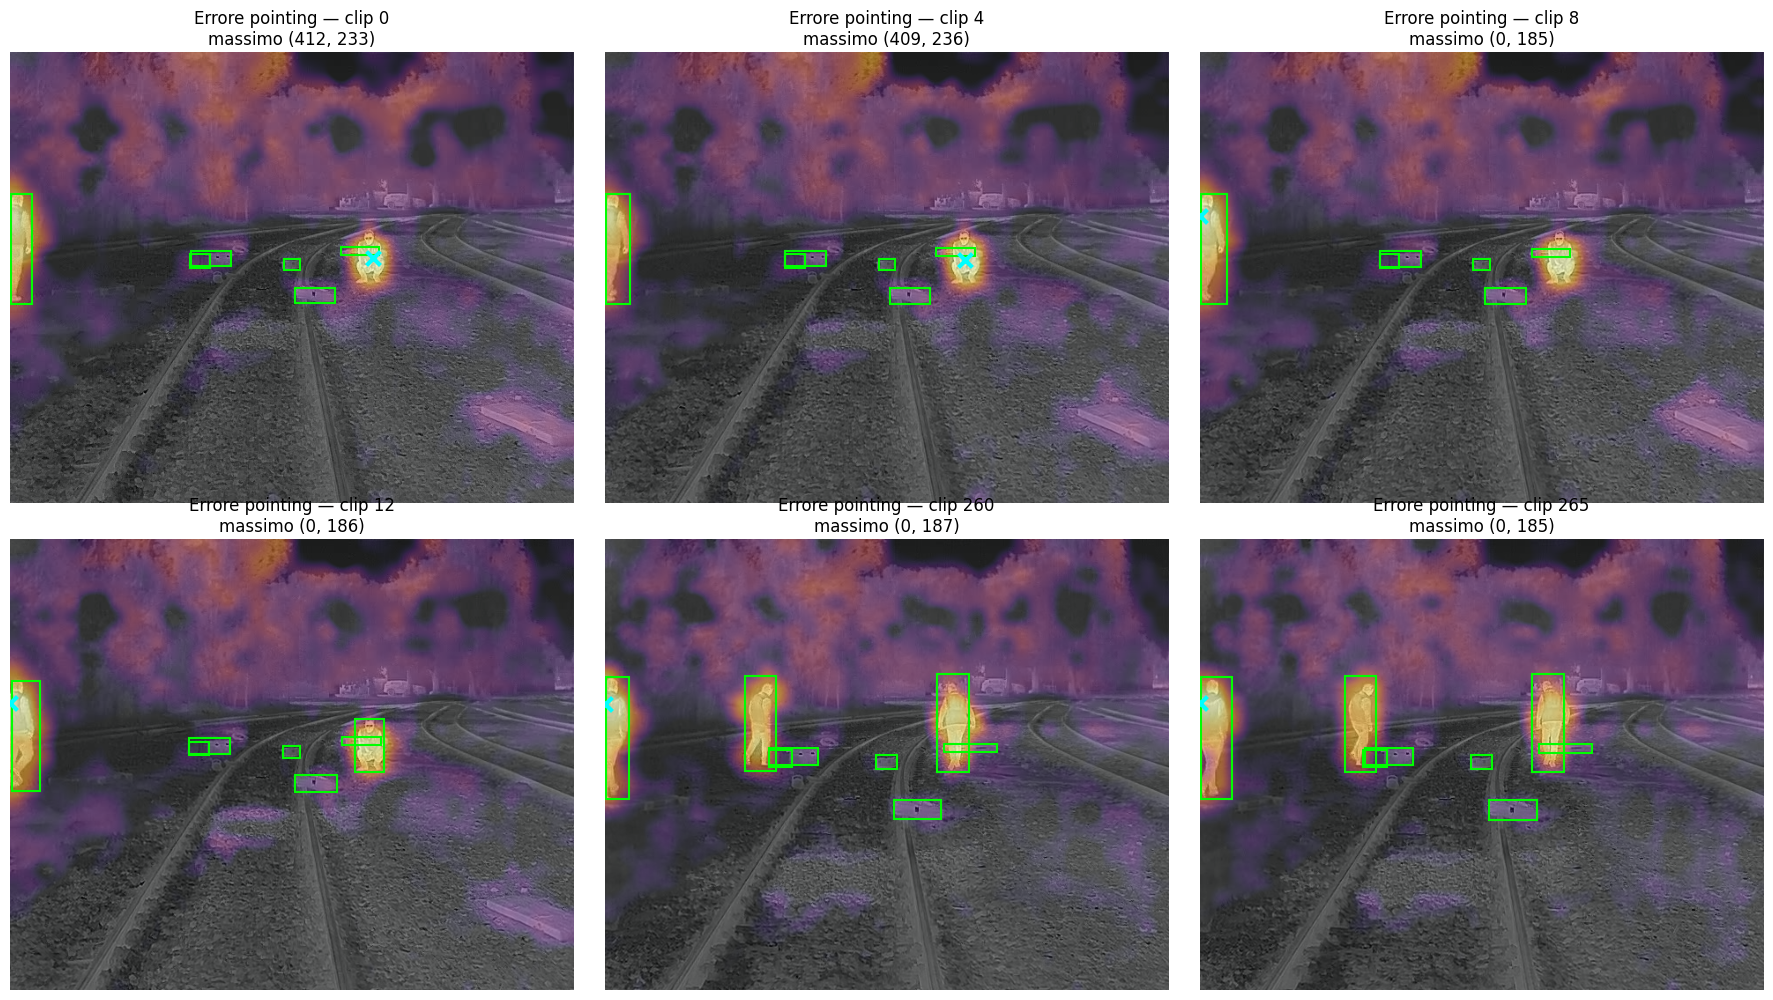

Errori pointing totali: 22


In [14]:
# Distribuzione degli score
plt.figure(figsize=(10, 6))

for role, color, label in [
    ("normal_calibration", "steelblue", "Normali calibrazione"),
    ("normal_test", "green", "Normali test"),
    ("anomaly_test", "darkorange", "Anomali"),
]:
    values = scores_df.loc[
        scores_df["role"] == role,
        "anomaly_score",
    ]

    plt.hist(
        values,
        bins=30,
        density=True,
        alpha=0.55,
        color=color,
        label=label,
    )

plt.axvline(
    anomaly_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Soglia {anomaly_threshold:.4f}",
)

plt.xlabel("Anomaly score")
plt.ylabel("Densità")
plt.title("E05-v1 — distribuzione degli anomaly score")
plt.legend()
plt.tight_layout()
plt.savefig(
    "/content/E05_score_distribution.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


# Sei esempi fra i 22 errori del pointing game
pointing_failures = pointing_df[
    pointing_df["hit_person"] == 0
].reset_index(drop=True)

selected_failure_positions = np.linspace(
    0,
    len(pointing_failures) - 1,
    min(6, len(pointing_failures)),
    dtype=int,
)

selected_failures = pointing_failures.iloc[
    selected_failure_positions
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, (_, failure) in zip(
    axes.ravel(),
    selected_failures.iterrows(),
):
    source_frame = int(failure["source_frame"])
    clip_frame = int(failure["clip_frame"])

    result_index = scores_df.index[
        (scores_df["role"] == "anomaly_test")
        & (scores_df["source_frame"] == source_frame)
    ][0]

    image = np.array(
        Image.open(
            anomaly_test_dir / f"anomaly_{clip_frame:05d}.jpg"
        ).convert("RGB")
    )
    full_map = upscale_anomaly_map(
        raw_maps_array[result_index]
    )

    axis.imshow(image)
    axis.imshow(
        full_map,
        cmap="inferno",
        alpha=0.48,
        vmin=localization_threshold,
        vmax=float(np.quantile(full_map, 0.999)),
    )

    frame_gt = person_gt[
        person_gt["frame"] == source_frame
    ]

    for _, box in frame_gt.iterrows():
        axis.add_patch(
            Rectangle(
                (box["xtl"], box["ytl"]),
                box["xbr"] - box["xtl"],
                box["ybr"] - box["ytl"],
                edgecolor="lime",
                facecolor="none",
                linewidth=1.5,
            )
        )

    axis.scatter(
        failure["max_x"],
        failure["max_y"],
        marker="x",
        s=100,
        linewidths=3,
        color="cyan",
    )

    axis.set_title(
        f"Errore pointing — clip {clip_frame}\n"
        f"massimo ({failure['max_x']}, {failure['max_y']})"
    )
    axis.axis("off")

for axis in axes.ravel()[len(selected_failures):]:
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    "/content/E05_pointing_failures.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Errori pointing totali:", len(pointing_failures))

In [15]:
import json
import zipfile
import hashlib
import subprocess
import sys
import sklearn
import scipy
import faiss

# Tabelle diagnostiche
score_statistics = (
    scores_df.groupby("role")["anomaly_score"]
    .agg(["count", "min", "median", "mean", "max"])
    .reset_index()
)

score_statistics.to_csv(
    "/content/E05_score_statistics.csv",
    index=False,
)
false_positive_df.to_csv(
    "/content/E05_normal_false_positives.csv",
    index=False,
)
pointing_failures.to_csv(
    "/content/E05_pointing_failures.csv",
    index=False,
)

visible_gt.to_csv(
    "/content/E05_visible_ground_truth_clip.csv",
    index=False,
)

manifest[
    manifest["split"] == "normal_reference"
].to_csv(
    "/content/E05_reference_selection.csv",
    index=False,
)

# SHA256 dei pesi DINOv2
weights_sha256 = "unknown"
weights_filename = "unknown"

checkpoint_dir = Path(torch.hub.get_dir()) / "checkpoints"
weight_candidates = list(
    checkpoint_dir.glob("*dinov2_vits14*.pth")
)

if weight_candidates:
    weights_path = weight_candidates[0]
    weights_filename = weights_path.name

    digest = hashlib.sha256()
    with open(weights_path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)

    weights_sha256 = digest.hexdigest()

# Metadati completi
metadata = {
    "experiment_id": "E05_v1_anomalydino_16shot",
    "date": "2026-07-05",
    "method": "AnomalyDINO",
    "training": False,
    "reference_based": True,
    "hardware": torch.cuda.get_device_name(0),

    "source_code": {
        "anomalydino_repository":
            "https://github.com/dammsi/AnomalyDINO",
        "anomalydino_commit":
            "b9d1c2648e3a5247437d4d953d907a8f3d994457",
        "dinov2_repository":
            "https://github.com/facebookresearch/dinov2",
        "dinov2_commit": dinov2_commit,
    },

    "model": {
        "backbone": MODEL_NAME,
        "resolution_short_edge": RESOLUTION,
        "patch_size": int(model.model.patch_size),
        "patch_grid": list(raw_maps_array.shape[1:]),
        "feature_dimension":
            int(reference_feature_blocks[0].shape[1]),
        "reference_images": len(reference_files),
        "memory_patches": int(normal_memory.shape[0]),
        "weights_filename": weights_filename,
        "weights_sha256": weights_sha256,
    },

    "preprocessing": {
        "normal_thermal_grayscale_converted_to_rgb": True,
        "reference_rotation_augmentation": False,
        "pca_background_masking": False,
        "reference_selection":
            "16 uniformly spaced images from first 160 normal frames",
    },

    "similarity_search": {
        "metric": "normalized_L2_equivalent_to_1_minus_cosine",
        "nearest_neighbors": 1,
        "backend": "exact_torch_cuda_matrix_multiplication",
        "note":
            "Same normalized nearest-neighbor distance as official FAISS path.",
    },

    "data_split": {
        "normal_reference": 16,
        "normal_reference_pool": 160,
        "normal_calibration": 20,
        "normal_test": 20,
        "anomaly_test": 500,
        "normal_source":
            "ir_2025-01-31_04-15-15.mp4",
        "anomaly_source":
            "test_video_san_donato.mp4 frames 2125-2624",
        "input_package_sha256":
            "db8118fc36199c2060a6214047a4df79580d359a9127796e7318f1b9d8141c2c",
    },

    "thresholds": {
        "image_score_statistic":
            "mean of largest 1 percent patch distances",
        "image_threshold_quantile": THRESHOLD_QUANTILE,
        "image_threshold": anomaly_threshold,
        "image_threshold_source":
            "20 normal calibration frames only",
        "absolute_localization_quantile":
            LOCALIZATION_QUANTILE,
        "absolute_localization_threshold":
            localization_threshold,
        "adaptive_localization_quantile":
            ADAPTIVE_QUANTILE,
        "minimum_component_area":
            MIN_COMPONENT_AREA,
    },

    "classification_results":
        classification_summary.iloc[0].to_dict(),

    "pointing_game_results":
        pointing_summary.to_dict("records"),

    "box_localization_results":
        box_summary.to_dict("records"),

    "limitations": [
        "Normal and anomalous samples come from different videos and different scenes.",
        "Perfect AUROC may partly reflect scene or domain shift rather than only anomalous objects.",
        "The 500 anomalous samples are temporally correlated frames from one 20-second clip.",
        "The four normal false positives are consecutive frames and are not independent errors.",
        "Only box ground truth is available; pixel-level segmentation metrics are not valid.",
        "The absolute spatial threshold fails under global scene shift.",
        "Adaptive top-1-percent thresholding is post-processing and is reported separately.",
        "DINOv2 patch maps are coarse, reducing box IoU for small objects.",
    ],
}

with open(
    "/content/E05_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
        ensure_ascii=False,
        default=lambda value:
            value.item()
            if isinstance(value, np.generic)
            else str(value),
    )

# Nota interpretativa
readme_text = f"""E05-v1 — AnomalyDINO 16-shot su immagini termiche ferroviarie

CLASSIFICAZIONE DI FRAME
Soglia scelta esclusivamente su 20 frame normali di calibrazione:
{anomaly_threshold:.6f}

Test indipendente:
- normali: 20
- anomali: 500
- TN: 16
- FP: 4
- FN: 0
- TP: 500
- precision: 0.992063
- recall: 1.000000
- F1: 0.996016
- AUROC: 1.000000
- average precision: 1.000000

LOCALIZZAZIONE
- pointing game persona: 478/500 = 0.956
- box top-1% a IoU 0.3: precision 0.744839, recall 0.241693, F1 0.364961
- box top-1% a IoU 0.5: precision 0.292320, recall 0.094855, F1 0.143233
- almeno una box con IoU >= 0.3 in tutti i 500 frame
- soglia spaziale assoluta non robusta al cambio globale di scenario

INTERPRETAZIONE
AnomalyDINO distingue nettamente i frame dei due video e localizza spesso
le persone come massimi della heatmap. Tuttavia il video normale e quello
anomalo mostrano scenari differenti: la separazione perfetta non dimostra
da sola che il metodo riconosca esclusivamente le anomalie. Vegetazione,
bordi e ballast producono attivazioni spurie. Le mappe patch sono troppo
grossolane per recuperare con IoU elevata tutte le piccole box CVAT.
"""

with open(
    "/content/E05_README.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(readme_text)

# Ambiente software
with open(
    "/content/E05_environment_freeze.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(
        subprocess.check_output(
            [sys.executable, "-m", "pip", "freeze"],
            text=True,
        )
    )

# Creazione ZIP
bundle_path = Path(
    "/content/E05_v1_anomalydino_16shot_results.zip"
)

files_to_archive = [
    ("/content/E05_metadata.json", "metadata.json"),
    ("/content/E05_README.txt", "README.txt"),
    (
        "/content/E05_environment_freeze.txt",
        "environment_freeze.txt",
    ),
    (
        "/content/E05_dataset_manifest.csv",
        "dataset_manifest.csv",
    ),
    (
        "/content/E05_reference_selection.csv",
        "reference_selection.csv",
    ),
    (
        "/content/E05_anomalydino_scores.csv",
        "scores.csv",
    ),
    (
        "/content/E05_score_statistics.csv",
        "score_statistics.csv",
    ),
    (
        "/content/E05_classification_summary.csv",
        "classification_summary.csv",
    ),
    (
        "/content/E05_raw_anomaly_maps.npz",
        "raw_anomaly_maps.npz",
    ),
    (
        "/content/E05_pointing_game_per_frame.csv",
        "pointing_game_per_frame.csv",
    ),
    (
        "/content/E05_pointing_game_summary.csv",
        "pointing_game_summary.csv",
    ),
    (
        "/content/E05_candidate_boxes.csv",
        "candidate_boxes.csv",
    ),
    (
        "/content/E05_box_localization_summary.csv",
        "box_localization_summary.csv",
    ),
    (
        "/content/E05_normal_false_positives.csv",
        "normal_false_positives.csv",
    ),
    (
        "/content/E05_pointing_failures.csv",
        "pointing_failures.csv",
    ),
    (
        "/content/E05_visible_ground_truth_clip.csv",
        "visible_ground_truth_clip.csv",
    ),
    (
        "/content/E05_probe_normal_vs_anomaly.png",
        "probe_normal_vs_anomaly.png",
    ),
    (
        "/content/E05_score_distribution.png",
        "score_distribution.png",
    ),
    (
        "/content/E05_anomalydino_qualitative_six_frames.png",
        "qualitative_six_frames.png",
    ),
    (
        "/content/E05_normal_false_positives.png",
        "normal_false_positives.png",
    ),
    (
        "/content/E05_pointing_failures.png",
        "pointing_failures.png",
    ),
]

with zipfile.ZipFile(
    bundle_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for source_path, archive_name in files_to_archive:
        archive.write(source_path, archive_name)

bundle_sha256 = hashlib.sha256(
    bundle_path.read_bytes()
).hexdigest()

print("Pacchetto:", bundle_path)
print(
    "Dimensione:",
    round(bundle_path.stat().st_size / 1024**2, 2),
    "MB",
)
print("SHA256:", bundle_sha256)

files.download(str(bundle_path))

Pacchetto: /content/E05_v1_anomalydino_16shot_results.zip
Dimensione: 15.33 MB
SHA256: c560204ae8c0a93e55e57ab30e28e1ef5b0eb6947e7ae48265ad2ebc8f3eca2a


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>